In [1]:
# Starts here
import numpy as np, pandas as pd, random, math, sys
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tslearn.clustering import TimeSeriesKMeans
from torch import nn, optim
from learning_shapelets import LearningShapelets
from sklearn.model_selection import train_test_split


In [2]:
'''
Train the data
'''
series = pd.read_csv('combined_sensorData.csv')


columns_to_combine = series.columns[:-1]
print(columns_to_combine)
print(columns_to_combine.size)

combined_array = []


Index(['ave_filt_force', 'ave_filt_xaxis', 'ave_filt_yaxis', 'ave_filt_zaxis',
       'med_filt_force', 'med_filt_xaxis', 'med_filt_yaxis', 'med_filt_zaxis'],
      dtype='object')
8


In [3]:
# Loop through each column, extract values, and append to combined_array
for column in columns_to_combine:
    new_array = series[column].to_numpy()
    print(new_array.size)
    combined_array.append(new_array)

combined_array = np.column_stack(combined_array)

y = series.iloc[:,-1].to_numpy() 
print(y)

label_map = {1: 0, 2: 1, 3: 2, 4: 3}
y = np.array([label_map[label] for label in y])
print(y)

# np.set_printoptions(threshold=np.inf)
print(combined_array)
print(type(combined_array))
print(combined_array.shape)




y = y[~np.isnan(y)]
print(y.shape)
print(y)
print(y.size)


X = combined_array.reshape(y.size,columns_to_combine.size,1)
# X = combined_array.reshape(720,6,5)

# X = combined_array.reshape(int(y.size/11),columns_to_combine.size,11) #Should be less than or requal to 
                                                                        # colums_to_combine.size
# X = combined_array.reshape(y.size,columns_to_combine.size,1)


print(X)
# np.unique(y)
# y = y.astype('<U1')
np.unique(y)
print(y)
print(X.shape)
print(y.shape)


def normalize_standard(X, scaler=None):
    shape = X.shape
    data_flat = X.flatten()
    if scaler is None:
        scaler = StandardScaler()
        data_transformed = scaler.fit_transform(data_flat.reshape(np.product(shape), 1)).reshape(shape)
    else:
        data_transformed = scaler.transform(data_flat.reshape(np.product(shape), 1)).reshape(shape)
    return data_transformed, scaler

def normalize_data(X, scaler=None):
    if scaler is None:
        X, scaler = normalize_standard(X)
    else:
        X, scaler = normalize_standard(X, scaler)
    
    return X, scaler





X, scaler = normalize_data(X)
print(f"X {X}")

print(f"Shape X: {X.shape}")
# print(f"Shape y_train: {y_train.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

print(X_train)
print(X_test)
print(y_train)
print(y_test)


def sample_ts_segments(X, shapelets_size, n_segments=10000):
    """
    Sample time series segments for k-Means.
    """
    n_ts, n_channels, len_ts = X.shape
    samples_i = random.choices(range(n_ts), k=n_segments)
    segments = np.empty((n_segments, n_channels, shapelets_size))
    for i, k in enumerate(samples_i):
        s = random.randint(0, len_ts - shapelets_size)
        segments[i] = X[k, :, s:s+shapelets_size]
    return segments


def get_weights_via_kmeans(X, shapelets_size, num_shapelets, n_segments=10000):
    """
    Get weights via k-Means for a block of shapelets.
    """
    segments = sample_ts_segments(X, shapelets_size, n_segments).transpose(0, 2, 1)
    k_means = TimeSeriesKMeans(n_clusters=num_shapelets, metric="euclidean", max_iter=50).fit(segments)
    clusters = k_means.cluster_centers_.transpose(0, 2, 1)
    return clusters


n_ts, n_channels, len_ts = X_train.shape
loss_func = nn.CrossEntropyLoss()
num_classes = len(set(y_train))
# learn 2 shapelets of length 130
shapelets_size_and_len = {1: 2}
dist_measure = "euclidean"
lr = 1e-2
wd = 1e-3
epsilon = 1e-7

print(X_train.shape)
print(n_ts)
print(n_channels)
print(len_ts)
print(shapelets_size_and_len)

learning_shapelets = LearningShapelets(shapelets_size_and_len=shapelets_size_and_len,
                                       in_channels=n_channels,
                                       num_classes=num_classes,
                                       loss_func=loss_func,
                                       to_cuda=False,
                                       verbose=1,
                                       dist_measure=dist_measure)

15804
15804
15804
15804
15804
15804
15804
15804
[1 1 1 ... 4 4 4]
[0 0 0 ... 3 3 3]
[[-6.000000e-02 -7.251000e+01  4.197900e+02 ... -7.200000e+01
   4.200000e+02 -2.506500e+03]
 [-6.000000e-02 -7.236000e+01  4.197600e+02 ... -7.200000e+01
   4.200000e+02 -2.506500e+03]
 [-6.000000e-02 -7.230000e+01  4.198200e+02 ... -7.200000e+01
   4.200000e+02 -2.506500e+03]
 ...
 [ 7.428000e+02  6.301050e+03  1.143756e+04 ...  6.393750e+03
   1.055925e+04 -6.287250e+03]
 [ 7.446600e+02  6.286950e+03  1.140882e+04 ...  6.318000e+03
   1.055925e+04 -5.970000e+03]
 [ 7.463000e+02  6.280680e+03  1.135842e+04 ...  6.318000e+03
   1.051425e+04 -5.638500e+03]]
<class 'numpy.ndarray'>
(15804, 8)
(15804,)
[0 0 0 ... 3 3 3]
15804
[[[-6.000000e-02]
  [-7.251000e+01]
  [ 4.197900e+02]
  ...
  [-7.200000e+01]
  [ 4.200000e+02]
  [-2.506500e+03]]

 [[-6.000000e-02]
  [-7.236000e+01]
  [ 4.197600e+02]
  ...
  [-7.200000e+01]
  [ 4.200000e+02]
  [-2.506500e+03]]

 [[-6.000000e-02]
  [-7.230000e+01]
  [ 4.198200e+02

In [4]:
for i, (shapelets_size, num_shapelets) in enumerate(shapelets_size_and_len.items()):
    weights_block = get_weights_via_kmeans(X_train, shapelets_size, num_shapelets)
    learning_shapelets.set_shapelet_weights_of_block(i, weights_block)

In [5]:
optimizer = optim.Adam(learning_shapelets.model.parameters(), lr=lr, weight_decay=wd, eps=epsilon)
learning_shapelets.set_optimizer(optimizer)

In [6]:
losses = learning_shapelets.fit(X_train, y_train, epochs=2000, batch_size=256, shuffle=False, drop_last=False)

Loss: 0.2717170715332031: 100%|██████████| 2000/2000 [05:09<00:00,  6.47it/s] 


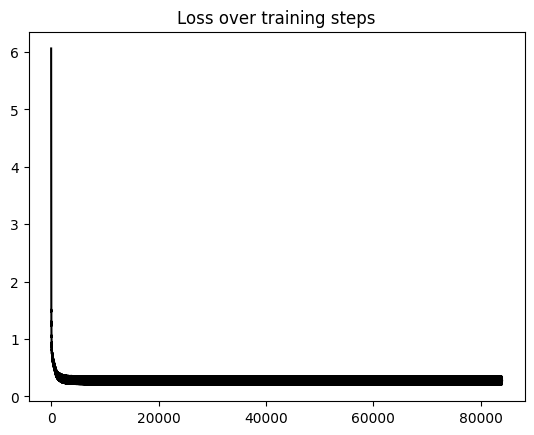

In [7]:
plt.plot(losses, color='black')
plt.title("Loss over training steps")
plt.show()

In [8]:


def eval_accuracy(model, X, Y):
    result = []
    predictions = model.predict(X)
    if len(predictions.shape) == 2:
        predictions = predictions.argmax(axis=1)
        print(predictions)
    print(type(predictions))
    print(predictions.shape)

    result.append(predictions)
    print(f"Accuracy: {(predictions == Y).sum() / Y.size}")
    return result




In [9]:
y_predlr = np.array(eval_accuracy(learning_shapelets, X_test, y_test)).reshape(-1)

print(y_predlr)
print(type(y_predlr))
print(y_predlr.shape)

# print(X_test)
# print(y_test)



[3 0 3 ... 1 1 1]
<class 'numpy.ndarray'>
(5216,)
Accuracy: 0.8983895705521472
[3 0 3 ... 1 1 1]
<class 'numpy.ndarray'>
(5216,)


In [36]:
print(X)

[[[ 1.34575329e-01]
  [ 1.20413401e-01]
  [ 2.16644138e-01]
  [-3.55491869e-01]
  [ 1.34587057e-01]
  [ 1.20513092e-01]
  [ 2.16685187e-01]
  [-3.55362858e-01]]

 [[ 1.34575329e-01]
  [ 1.20442722e-01]
  [ 2.16638274e-01]
  [-3.55491869e-01]
  [ 1.34587057e-01]
  [ 1.20513092e-01]
  [ 2.16685187e-01]
  [-3.55362858e-01]]

 [[ 1.34575329e-01]
  [ 1.20454450e-01]
  [ 2.16650003e-01]
  [-3.55491869e-01]
  [ 1.34587057e-01]
  [ 1.20513092e-01]
  [ 2.16685187e-01]
  [-3.55362858e-01]]

 [[ 1.34571419e-01]
  [ 1.20460314e-01]
  [ 2.16644138e-01]
  [-3.55491869e-01]
  [ 1.34587057e-01]
  [ 1.20513092e-01]
  [ 2.16685187e-01]
  [-3.55362858e-01]]

 [[ 1.34567510e-01]
  [ 1.20472043e-01]
  [ 2.16650003e-01]
  [-3.55486005e-01]
  [ 1.34587057e-01]
  [ 1.20513092e-01]
  [ 2.16685187e-01]
  [-3.55362858e-01]]

 [[ 1.34563600e-01]
  [ 1.20442722e-01]
  [ 2.16650003e-01]
  [-3.55474277e-01]
  [ 1.34587057e-01]
  [ 1.20513092e-01]
  [ 2.16685187e-01]
  [-3.55362858e-01]]

 [[ 1.34567510e-01]
  [ 1.20

In [35]:
import numpy as np
import torch

x_test1 = [[ 1.34532325e-01],
  [ 1.21439628e-01],
  [ 2.17295059e-01],
  [-3.55714707e-01],
  [ 1.34587057e-01],
  [ 1.21539318e-01],
  [ 2.17271603e-01],
  [-3.55656066e-01]]


# Convert x_test1 to a numpy array
x_test1_np = np.array(x_test1)

# Reshape to match the required tensor shape (assuming len_ts = 1)
x_test1_tensor = torch.tensor(x_test1_np.reshape(-1, 1, 1), dtype=torch.float)

print(x_test1_tensor)

# x_test1 = [ 1.34532325e-01,
#    1.21439628e-01,
#    2.17295059e-01,
#   -3.55714707e-01,
#    1.34587057e-01,
#    1.21539318e-01,
#    2.17271603e-01,
#   -3.55656066e-01]

# x_test2 =  [[ 1.34540144e-01]
#   [ 1.18003234e-01]
#   [ 2.15711738e-01]
#   [-3.58623327e-01]
#   [ 1.34587057e-01]
#   [ 1.18167431e-01]
#   [ 2.15805565e-01]
#   [-3.58588142e-01]]


# x_test3 =  [[ 1.34602695e-01]
#   [ 1.26119221e-01]
#   [ 2.57951226e-01]
#   [-5.52087571e-01]
#   [ 1.34587057e-01]
#   [ 1.21392714e-01]
#   [ 2.19910471e-01]
#   [-5.86850266e-01]]

# x_test4 =  [[ 2.20657173e-01]
#   [ 8.96270056e-01]
#   [ 1.64589049e+00]
#   [-2.31570788e+00]
#   [ 2.60079914e-01]
#   [ 1.14849897e+00]
#   [ 1.44302601e+00]
#   [-2.53067011e+00]]


X_test_scaled1 = learning_shapelets.transform(x_test1_tensor)
# X_test_scaled2 = learning_shapelets.transform(x_test2)
# X_test_scaled3 = learning_shapelets.transform(x_test3)
# X_test_scaled4 = learning_shapelets.transform(x_test4)

print(X_test_scaled1)



tensor([[[ 0.1345]],

        [[ 0.1214]],

        [[ 0.2173]],

        [[-0.3557]],

        [[ 0.1346]],

        [[ 0.1215]],

        [[ 0.2173]],

        [[-0.3557]]])
[[1.1953492 3.3003876]
 [1.1838789 3.3265731]
 [1.4846945 3.168204 ]
 [3.1061902 4.5785136]
 [1.1954587 3.3002784]
 [1.1838789 3.3263738]
 [1.4845068 3.1682043]
 [3.1058383 4.578279 ]]
